*italicized text*# **HW8 – Quantum CNNs, GNNs, Bayes, and K-Means**
_Time required: ~2–3 hours (for students with Qiskit ML experience)_

**What you’ll practice**
- Building quanvolutional layers for QCNNs
- Encoding graphs and message passing in QGNNs
- Quantum Bayesian inference with phase estimation
- Quantum distance estimation for K-means clustering
- Hybrid implementations and evaluations
- Noise impact and mitigations

**What to turn in**
- This single notebook (`HW10_YourName.ipynb`) with **all cells run**, code and short written answers filled in where prompted.

**Rules & hints**
- Use **Qiskit** (version ~1.0 or later), **Qiskit Machine Learning**.
- Use AerSimulator for reproducibility.
- If stuck, explain reasoning; partial credit for clear work.
- Use MNIST digits (small 4x4) for QCNN; MUTAG graphs (small subset) for GNN; toy probs for Bayes/K-means.
- Focus on small scales: 2-4 qubits, reps=1.


In [1]:
# --- Setup (run me first) ---
# Install if needed (uncomment in Colab)
!pip install "qiskit[visualization]"
!pip install qiskit_aer
!pip install qiskit-ibm-runtime
!pip install qiskit-machine-learning

# Import necessary modules
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit.circuit.library import ZZFeatureMap, TwoLocal
from qiskit_machine_learning.neural_networks import EstimatorQNN
from sklearn import datasets, metrics
from sklearn.cluster import KMeans
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Simulator backend
sim = AerSimulator()

# Function to run circuit and get counts
def get_counts(circ, shots=1024):
    tc = transpile(circ, sim)
    result = sim.run(tc, shots=shots).result()
    return result.get_counts()

def assert_close(A, B, tol=1e-4):
    if not np.allclose(A, B, atol=tol):
        raise AssertionError(f"Not close: {A} vs {B}")


## Part A — Quantum CNNs (Session 14) (≈30 min)

Explain what we've done here. What good is it?  How would this fit in a hybrid workflow?


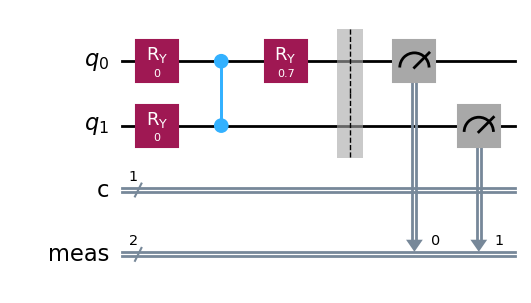

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from qiskit import QuantumCircuit
from qiskit_aer.primitives import SamplerV2 as Sampler

# ---------------------------
# Load digits & normalize
# ---------------------------
digits = datasets.load_digits()
img4x4 = digits.images[0][:4, :4] / 16.0  # normalize
params = 0.7  # example variational parameter

# ---------------------------
# A1. Single patch example
# ---------------------------
patch = img4x4[0:2, 0:2].flatten()[:2]  # take first 2 pixels for 2 qubits
qc_quanv = QuantumCircuit(2, 1)

# Encode Ry rotations
for i in range(2):
    qc_quanv.ry(patch[i] * np.pi, i)

# Entangling
qc_quanv.cz(0, 1)

# Variational layer
qc_quanv.ry(params, 0)

# Measure qubit 0 for <Z>
qc_quanv.measure_all()
qc_quanv.draw('mpl')


In [53]:
# Sample with SamplerV2
sampler = Sampler()
job = sampler.run([qc_quanv], shots=5000)
res = job.result()
counts = res[0].data.meas.get_counts()

# Compute <Z> from measurement probabilities
n0 = counts.get('00', 0) + counts.get('01', 0)  # q0=0
n1 = counts.get('10', 0) + counts.get('11', 0)  # q0=1
z_exp_sampled = (n0 - n1) / (n0 + n1)
print("<Z> sampled:", z_exp_sampled)

<Z> sampled: 1.0


In [54]:
# ---------------------------
# A2. Full feature map (stride-1, 3x3 patches)
# ---------------------------
features = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        patch = img4x4[i:i+2, j:j+2].flatten()[:2]
        qc = QuantumCircuit(2, 1)
        for k in range(2):
            qc.ry(patch[k] * np.pi, k)
        qc.cz(0, 1)
        qc.ry(params, 0)
        qc.measure_all()

        # Sample
        job = sampler.run([qc], shots=5000)
        res = job.result()
        counts = res[0].data.meas.get_counts()
        n0 = counts.get('00',0) + counts.get('01',0)
        n1 = counts.get('10',0) + counts.get('11',0)
        features[i,j] = (n0 - n1)/(n0 + n1)

print("Quanv features shape:", features.shape)
print(features)

Quanv features shape: (3, 3)
[[ 1.      0.5536 -0.8408]
 [ 1.     -0.8372 -0.98  ]
 [ 0.8252 -0.9712  0.916 ]]


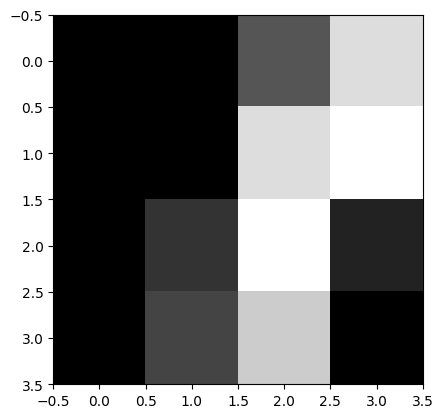

In [57]:
plt.imshow(img.reshape(4,4), cmap='gray')

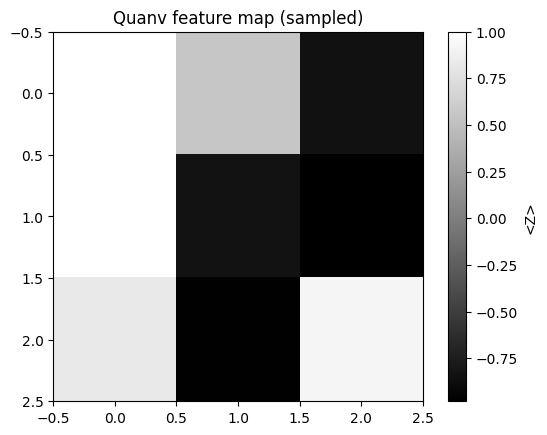

In [55]:
plt.imshow(features, cmap='gray')
plt.colorbar(label="<Z>")
plt.title("Quanv feature map (sampled)")
plt.show()


I haven't fully implemented this into a CNN, but what can we use these features for?

## Part B — Quantum GNNs (Session 15) (≈45 min)

Explain what we've done here. What good is it?  How would this fit in a hybrid workflow?



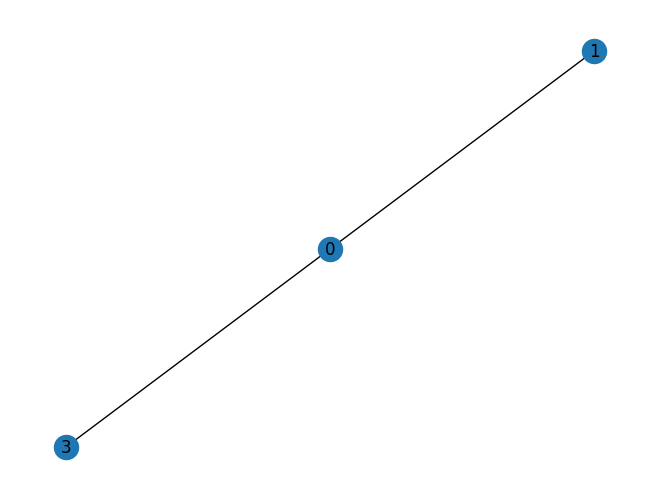

Aggregated:  -0.04269062861042181


In [10]:
# ---------------------------
# B1. Graph encode
# ---------------------------
G = nx.cycle_graph(4)
nx.set_node_attributes(G, {i: np.random.rand(2) for i in G.nodes}, 'feat')
ego_0 = nx.ego_graph(G, 0, radius=1)

nx.draw(ego_0, with_labels=True)
plt.show()

# ---------------------------
# B2. Message passing
# ---------------------------
# Use 2 qubits for ego node + neighbor (simplified)
theta = 0.5  # example variational param
Z = np.array([[1,0],[0,-1]])
ZI = np.kron(Z, np.eye(2))

# Compute <Z> for each neighbor + self
Z_values = []
for node in ego_0.nodes:
    feat = G.nodes[node]['feat']
    qc_mp = QuantumCircuit(2)

    # Encode node + a dummy neighbor feature (if node is ego 0, neighbors are others)
    # We'll just take first 2 features as 2 qubit Ry rotations
    for i in range(2):
        qc_mp.ry(feat[i]*np.pi, i)

    # Entangle
    qc_mp.cx(0, 1)

    # Variational rotation
    qc_mp.ry(theta, 0)

    # Compute <Z> on qubit 0
    sv = Statevector.from_instruction(qc_mp).data
    Z_val = np.real(np.vdot(sv, ZI.dot(sv)))
    Z_values.append(Z_val)

# Aggregate messages for ego node 0
agg = np.mean(Z_values)
print("Aggregated: ", agg)

## Part C — Quantum Bayes (Session 16) (≈45 min)

1. Explain how this works
2. Play with the number of shots.  How does that affect the accuracy?  
3. Experiment with how noise affects the circuit.

Don't touch my cells, add yours below it.



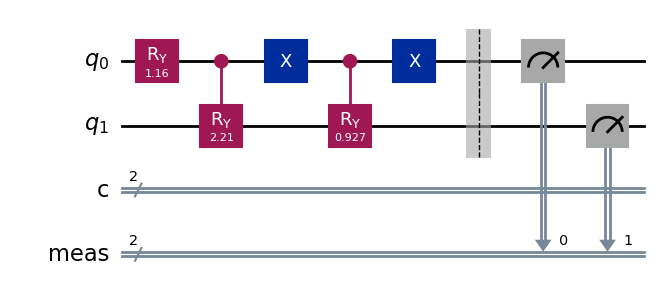

In [38]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer.primitives import SamplerV2 as Sampler
import matplotlib.pyplot as plt





In [48]:
SHOTS = 128
def run_bayes():
  # ---------------------------
  # Model parameters
  # ---------------------------
  pX = 0.3              # P(X=1)
  pY_given_X1 = 0.8     # P(Y=1 | X=1)
  pY_given_X0 = 0.2     # P(Y=1 | X=0)

  # Convert probabilities to angles for Ry rotations
  theta_x = 2 * np.arcsin(np.sqrt(pX))
  theta_y1 = 2 * np.arcsin(np.sqrt(pY_given_X1))
  theta_y0 = 2 * np.arcsin(np.sqrt(pY_given_X0))

  # ---------------------------
  # C1. Build circuit
  # ---------------------------
  qc = QuantumCircuit(2, 2)  # q0 = X, q1 = Y

  # Prepare prior P(X)
  qc.ry(theta_x, 0)

  # Prepare likelihood conditioned on X=1
  qc.cry(theta_y1, 0, 1)

  # Prepare likelihood conditioned on X=0
  qc.x(0)           # flip X -> control on |0>
  qc.cry(theta_y0, 0, 1)
  qc.x(0)           # flip back

  # Measure both qubits
  qc.measure_all()

  # Draw circuit
  qc.draw('mpl')
  # ---------------------------
  # C2. Sample and extract posterior
  # ---------------------------
  sampler = Sampler()
  shots = SHOTS
  job = sampler.run([qc], shots=shots)
  res = job.result()
  counts = res[0].data.meas.get_counts()

  # Plot measurement histogram
  plot_histogram(counts, figsize=(6,2))
  plt.show()

  # Compute P(X=1 | Y=1) from measured counts
  # Counts keys: 'q1q0' (note little-endian, q1=Y, q0=X)
  n_Y1 = counts.get('11',0) + counts.get('10',0)
  n_Y1X1 = counts.get('11',0)
  posterior_quantum = n_Y1X1 / n_Y1
  print("Quantum posterior P(X=1|Y=1):", posterior_quantum)

  # Classical Bayes for comparison
  posterior_classical = (pY_given_X1 * pX) / (pY_given_X1*pX + pY_given_X0*(1-pX))
  print("Classical Bayes P(X=1|Y=1):", posterior_classical)
run_bayes()

Quantum posterior P(X=1|Y=1): 0.5892857142857143
Classical Bayes P(X=1|Y=1): 0.631578947368421


In [ ]:
SHOTS = 128
run_bayes()

## Part D — Quantum K-Means (Session 17) (≈30 min)

Evaluate the following code.  Can you get a better result by making minor changes to the circuit?  How does that scale as you increase the number of datapoints?  How does this scale with noise?  Show me both your explorations and your explanations.  Do not rewrite my cells!  Add yours below it.


Computing small quantum kernel matrix (8 points, 512 shots each entry)...
Kernel matrix computed (shape (8, 8))
Adjusted Rand Index (Quantum-kernel KMeans): -0.120
Adjusted Rand Index (Classical KMeans):       0.125


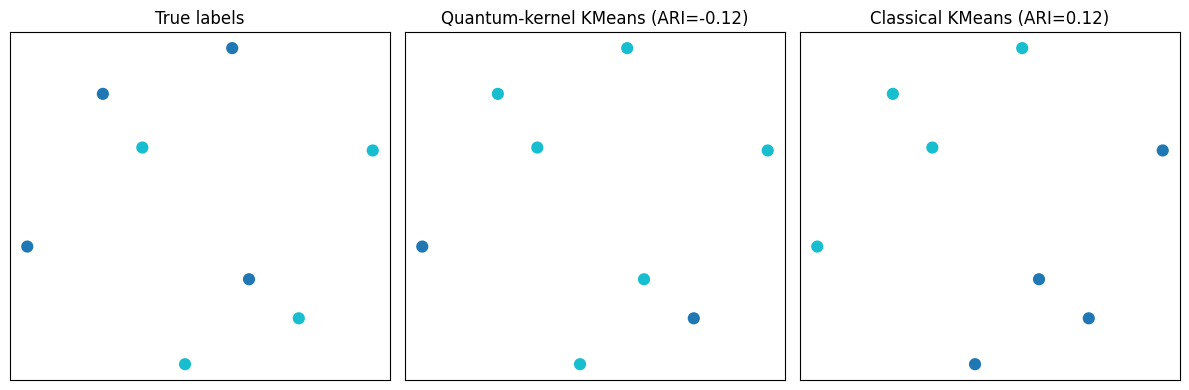

Kernel matrix (rounded):
[[  1.  47.   0.  18. 447. 119. 123.  14.]
 [ 47.   1. 136. 143.  21.  18. 323. 112.]
 [  0. 136.   1.  84.  37. 159. 141. 482.]
 [ 18. 143.  84.   1.   6. 118.  16.  82.]
 [447.  21.  37.   6.   1.  99.  89.  22.]
 [119.  18. 159. 118.  99.   1. 273. 222.]
 [123. 323. 141.  16.  89. 273.   1. 113.]
 [ 14. 112. 482.  82.  22. 222. 113.   1.]]


In [43]:
# Simple Quantum K-means demo (classroom-ready)
# pip install qiskit qiskit-aer numpy scikit-learn matplotlib

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import SpectralEmbedding
from sklearn.metrics import adjusted_rand_score
from qiskit.circuit.library import zz_feature_map
from qiskit import QuantumCircuit
from qiskit_aer.primitives import SamplerV2 as Sampler

# ---------- Parameters ----------
N_POINTS = 8        # very small for classroom demo
SHOTS = 512         # small shot budget; increase for stability
REPS = 1           # feature map repetitions
RANDOM_SEED = 0



# ---------- 3) Simple helper: compute kernel entry K(x,y) = |<0|U(x)^\dagger U(y)|0>|^2 ----------
def compute_kernel_entry_simple(x, y, fmap, shots=512):
    """Bind x,y into a circuit U(y) * U(x)^dagger and measure probability of |0...0>."""
    params = list(fmap.parameters)
    if len(params) != len(x):
        raise ValueError("Input length doesn't match feature map parameters")
    Ux = fmap.assign_parameters({p: float(v) for p, v in zip(params, x)})
    Uy = fmap.assign_parameters({p: float(v) for p, v in zip(params, y)})
    qc = QuantumCircuit(fmap.num_qubits, fmap.num_qubits)
    qc.compose(Uy, inplace=True)
    qc.compose(Ux.inverse(), inplace=True)
    qc.measure_all()
    sampler = Sampler()
    job = sampler.run([qc], shots=shots)
    res = job.result()
    pdict =res[0].data.meas.get_counts()
    key = '0' * fmap.num_qubits
    p0 = pdict.get(key, 0.0)
    return float(p0)
def k_means_main():
  # ---------- 1) Small toy dataset ----------
  X_raw, y_true = make_moons(n_samples=N_POINTS, noise=0.12, random_state=RANDOM_SEED)
  scaler = StandardScaler().fit(X_raw)
  X_scaled = scaler.transform(X_raw)           # standardize for angle mapping

  # map features into angle domain [-pi, pi] simply (small demo)
  X_angles = (X_scaled / np.max(np.abs(X_scaled))) * np.pi

  # ---------- 2) Define a shallow feature map ----------
  feature_map = zz_feature_map(feature_dimension=2, reps=REPS)  # 2D input expected
  # feature_map.parameters order typically [x0, x1]; ensure we supply matching arrays
  # ---------- 4) Build small quantum kernel matrix (symmetric) ----------
  N = len(X_angles)
  Kmat = np.eye(N)
  print("Computing small quantum kernel matrix ({} points, {} shots each entry)...".format(N, SHOTS))
  for i in range(N):
      for j in range(i+1, N):
          k = compute_kernel_entry_simple(X_angles[i], X_angles[j], feature_map, shots=SHOTS)
          Kmat[i, j] = Kmat[j, i] = k

  print("Kernel matrix computed (shape {})".format(Kmat.shape))

  # ---------- 5) Kernel K-means via spectral embedding -> KMeans ----------
  n_clusters = 2
  Z = SpectralEmbedding(n_components=n_clusters, affinity='precomputed').fit_transform(Kmat)
  labels_qk = KMeans(n_clusters=n_clusters, n_init=10, random_state=RANDOM_SEED).fit_predict(Z)

  # Baseline classical KMeans on Euclidean scaled inputs
  labels_km = KMeans(n_clusters=n_clusters, n_init=10, random_state=RANDOM_SEED).fit_predict(X_scaled)

  # ---------- 6) Evaluate and plot ----------
  ari_qk = adjusted_rand_score(y_true, labels_qk)
  ari_km = adjusted_rand_score(y_true, labels_km)
  print(f"Adjusted Rand Index (Quantum-kernel KMeans): {ari_qk:.3f}")
  print(f"Adjusted Rand Index (Classical KMeans):       {ari_km:.3f}")

  # plot results: raw data with true labels, quantum-kernel labels, classical kmeans labels
  fig, axes = plt.subplots(1, 3, figsize=(12, 4))
  axes[0].scatter(X_raw[:,0], X_raw[:,1], c=y_true, cmap='tab10', s=60)
  axes[0].set_title("True labels")
  axes[1].scatter(X_raw[:,0], X_raw[:,1], c=labels_qk, cmap='tab10', s=60)
  axes[1].set_title(f"Quantum-kernel KMeans (ARI={ari_qk:.2f})")
  axes[2].scatter(X_raw[:,0], X_raw[:,1], c=labels_km, cmap='tab10', s=60)
  axes[2].set_title(f"Classical KMeans (ARI={ari_km:.2f})")
  for ax in axes:
      ax.set_xticks([]); ax.set_yticks([])
  plt.tight_layout()
  plt.show()

  # ---------- 7) Quick diagnostics: print kernel matrix ----------
  print("Kernel matrix (rounded):")
  with np.printoptions(precision=3, suppress=True):
      print(Kmat)
k_means_main()

In [ ]:
_POINTS = #
SHOTS = #
REPS = #
RANDOM_SEED = 0
k_means_main()